# Experiment results analysis

Parse ensemble and deep-learning experiments into separate validation-ranked tables. Model selection must use validation performance. test metrics are shown only for final reporting.

In [25]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", None)

In [26]:
experiments_dir = Path("../experiments")

def first_present(metrics, *keys, default=None):
    return next((metrics[key] for key in keys if key in metrics), default)


def parse_experiment(path):
    metrics = json.loads(path.read_text(encoding="utf-8"))
    relative_path = path.relative_to(experiments_dir)
    return {
        "model": first_present(metrics, "model", "winning_model"),
        "feature_strategy": first_present(
            metrics, "feature_strategy", "winning_feature_strategy"
        ),
        "sampling_strategy": first_present(
            metrics, "sampling_strategy", "winning_sampling_strategy"
        ),
        "loss": metrics.get("loss"),
        "validation_average_precision": first_present(
            metrics,
            "best_validation_average_precision",
            "validation_average_precision",
        ),
        "test_roc_auc": metrics.get("test_roc_auc"),
        "test_average_precision": first_present(
            metrics, "test_average_precision", "test_averagep_precision"
        ),
        "best_params": metrics.get("best_params", {}),
        "validation_start": metrics.get("validation_start"),
        "test_start": metrics.get("test_start"),
        "experiment_time": relative_path.parts[-2] if len(relative_path.parts) >= 2 else None,
        "metrics_path": str(relative_path),
    }


ensemble_metric_files = sorted(
    path for path in experiments_dir.rglob("metrics.json")
    if path.relative_to(experiments_dir).parts[0] != "deep"
)
if not ensemble_metric_files:
    raise FileNotFoundError(f"No ensemble metrics.json files found below {experiments_dir.resolve()}")

ensemble_results = pd.DataFrame(parse_experiment(path) for path in ensemble_metric_files)
numeric_columns = [
    "validation_average_precision",
    "test_roc_auc",
    "test_average_precision",
]
ensemble_results[numeric_columns] = ensemble_results[numeric_columns].apply(pd.to_numeric, errors="coerce")
ensemble_results = ensemble_results.sort_values(
    "validation_average_precision", ascending=False, na_position="last"
).reset_index(drop=True)
ensemble_results.index = ensemble_results.index + 1
ensemble_results.index.name = "validation_rank"

print(f"Loaded {len(ensemble_results):,} ensemble experiments from {experiments_dir.resolve()}")

Loaded 52 ensemble experiments from /home/vahid/Projects/pythonProject/ABNAmro_assignment/experiments


In [27]:
summary_columns = [
    "model",
    "feature_strategy",
    "sampling_strategy",
    "validation_average_precision",
    "test_roc_auc",
    "test_average_precision",
    "experiment_time",
    "metrics_path",
]
display(ensemble_results[summary_columns].style.format({
    "validation_average_precision": "{:.6f}",
    "test_roc_auc": "{:.6f}",
    "test_average_precision": "{:.6f}",
}, na_rep="—"))

,model,feature_strategy,sampling_strategy,validation_average_precision,test_roc_auc,test_average_precision,experiment_time,metrics_path
validation_rank,,,,,,,,
1,xgboost,all,random_over,0.975271,0.998846,0.951650,20260808_042906_458730_+0200,xgboost/20260808_042906_458730_+0200/metrics.json
2,catboost,all,none,0.973164,0.998858,0.952522,20260807_205759_980874_+0200,catboost/20260807_205759_980874_+0200/metrics.json
3,xgboost,all,none,0.972792,0.998843,0.948714,20260808_041014_896622_+0200,xgboost/20260808_041014_896622_+0200/metrics.json
4,lightgbm,all,none,0.969419,0.998849,0.946438,20260807_144543_249656_+0200,lightgbm/20260807_144543_249656_+0200/metrics.json
5,lightgbm,all,none,0.969419,0.998849,0.946438,20260807_193725_615611_+0200,lightgbm/20260807_193725_615611_+0200/metrics.json
6,lightgbm,all,none,0.969419,0.998849,0.946438,20260807_165132_307814_+0200,lightgbm/20260807_165132_307814_+0200/metrics.json
7,xgboost,all,random_under,0.943894,0.998511,0.915993,20260808_041153_138282_+0200,xgboost/20260808_041153_138282_+0200/metrics.json
8,xgboost,behavioral,random_over,0.942783,0.997821,0.889399,20260808_034339_689327_+0200,xgboost/20260808_034339_689327_+0200/metrics.json
9,lightgbm,behavioral,random_over,0.938763,0.998448,0.904606,20260808_014002_489172_+0200,lightgbm/20260808_014002_489172_+0200/metrics.json


In [28]:
eligible = ensemble_results.dropna(subset=["validation_average_precision"])
if eligible.empty:
    raise ValueError("No experiment contains validation average precision.")

best = eligible.iloc[0]
best_configuration = pd.DataFrame({
    "value": {
        "model": best["model"],
        "feature_strategy": best["feature_strategy"],
        "sampling_strategy": best["sampling_strategy"],
        "loss": best["loss"],
        "best_validation_average_precision": best["validation_average_precision"],
        "test_roc_auc": best["test_roc_auc"],
        "test_average_precision": best["test_average_precision"],
        "best_params": json.dumps(best["best_params"], indent=2, sort_keys=True),
        "metrics_path": best["metrics_path"],
    }
})
display(best_configuration)

,value
model,xgboost
feature_strategy,all
sampling_strategy,random_over
loss,None
best_validation_average_precision,0.975271
test_roc_auc,0.998846
test_average_precision,0.95165
best_params,"{\n ""model__colsample_bytree"": 0.85,\n ""model__learning_rate"": 0.02,\n ""model__max_depth"": 8,\n ""model__n_estima..."
metrics_path,xgboost/20260808_042906_458730_+0200/metrics.json


In [29]:
best_per_model = (
    eligible.sort_values("validation_average_precision", ascending=False)
    .drop_duplicates(subset=["model"], keep="first")
    .sort_values("validation_average_precision", ascending=False)
)
display(best_per_model[summary_columns].style.format({
    "validation_average_precision": "{:.6f}",
    "test_roc_auc": "{:.6f}",
    "test_average_precision": "{:.6f}",
}, na_rep="—"))

,model,feature_strategy,sampling_strategy,validation_average_precision,test_roc_auc,test_average_precision,experiment_time,metrics_path
validation_rank,,,,,,,,
1,xgboost,all,random_over,0.975271,0.998846,0.951650,20260808_042906_458730_+0200,xgboost/20260808_042906_458730_+0200/metrics.json
2,catboost,all,none,0.973164,0.998858,0.952522,20260807_205759_980874_+0200,catboost/20260807_205759_980874_+0200/metrics.json
4,lightgbm,all,none,0.969419,0.998849,0.946438,20260807_144543_249656_+0200,lightgbm/20260807_144543_249656_+0200/metrics.json
25,rusboost,all,none,0.879944,0.995272,0.848005,20260807_191806_658123_+0200,rusboost/20260807_191806_658123_+0200/metrics.json
45,easyensemble,all,none,0.726219,0.984515,0.647851,20260807_193222_910773_+0200,easyensemble/20260807_193222_910773_+0200/metrics.json


In [30]:
deep_metric_files = sorted((experiments_dir / "deep").rglob("metrics.json"))
deep_rows = []

for path in deep_metric_files:
    metrics = json.loads(path.read_text(encoding="utf-8"))
    config = metrics.get("config", {})
    deep_rows.append({
        "model": metrics.get("model", config.get("model_name")),
        "feature_strategy": metrics.get("feature_strategy", config.get("feature_strategy")),
        "loss": metrics.get("loss", config.get("loss_name")),
        "validation_average_precision": metrics.get("best_validation_average_precision"),
        "test_roc_auc": metrics.get("test_roc_auc"),
        "test_average_precision": metrics.get("test_average_precision"),
        "selected_epochs": metrics.get("selected_epochs"),
        "learning_rate": config.get("learning_rate"),
        "batch_size": config.get("batch_size"),
        "deviation_weight": config.get("deviation_weight"),
        "deviation_margin": config.get("deviation_margin"),
        "experiment_time": path.parent.name,
        "metrics_path": str(path.relative_to(experiments_dir)),
    })

deep_results = pd.DataFrame(deep_rows)
if deep_results.empty:
    print(f"No deep-learning metrics found below {(experiments_dir / 'deep').resolve()}")
else:
    deep_results = deep_results.sort_values(
        "validation_average_precision", ascending=False, na_position="last"
    ).reset_index(drop=True)
    deep_results.index = deep_results.index + 1
    deep_results.index.name = "validation_rank"
    best_deep_per_model = deep_results.drop_duplicates("model", keep="first")
    print(f"Loaded {len(deep_results):,} deep-learning experiments")
    print("Best deep-learning run overall (selected by validation AP):")
    display(deep_results.head(1))
    print("Best run for each deep-learning model:")
    display(best_deep_per_model)
    print("All deep-learning runs:")
    display(deep_results.style.format({
        "validation_average_precision": "{:.6f}",
        "test_roc_auc": "{:.6f}",
        "test_average_precision": "{:.6f}",
        "learning_rate": "{:.6g}",
    }, na_rep="—"))

Loaded 22 deep-learning experiments
Best deep-learning run overall (selected by validation AP):


,model,feature_strategy,loss,validation_average_precision,test_roc_auc,test_average_precision,selected_epochs,learning_rate,batch_size,deviation_weight,deviation_margin,experiment_time,metrics_path
validation_rank,,,,,,,,,,,,,
1,ft_transformer,all,focal,0.93908,0.996345,0.897317,26,0.0001,2048,1.0,5.0,20260807_194007_421937_+0200,deep/ft_transformer/20260807_194007_421937_+0200/metrics.json


Best run for each deep-learning model:


,model,feature_strategy,loss,validation_average_precision,test_roc_auc,test_average_precision,selected_epochs,learning_rate,batch_size,deviation_weight,deviation_margin,experiment_time,metrics_path
validation_rank,,,,,,,,,,,,,
1,ft_transformer,all,focal,0.939080,0.996345,0.897317,26,0.0001,2048,1.00,5.0,20260807_194007_421937_+0200,deep/ft_transformer/20260807_194007_421937_+0200/metrics.json
5,tabm,time,weighted_bce+deviation,0.756457,0.948665,0.729410,20,0.0001,2048,10.25,5.0,20260807_184900_444751_+0200,deep/tabm/20260807_184900_444751_+0200/metrics.json


All deep-learning runs:


,model,feature_strategy,loss,validation_average_precision,test_roc_auc,test_average_precision,selected_epochs,learning_rate,batch_size,deviation_weight,deviation_margin,experiment_time,metrics_path
validation_rank,,,,,,,,,,,,,
1,ft_transformer,all,focal,0.939080,0.996345,0.897317,26,0.0001,2048,1.000000,5.000000,20260807_194007_421937_+0200,deep/ft_transformer/20260807_194007_421937_+0200/metrics.json
2,ft_transformer,all,weighted_bce+deviation,0.933109,0.994474,0.899026,24,0.0001,2048,0.250000,5.000000,20260807_200215_368590_+0200,deep/ft_transformer/20260807_200215_368590_+0200/metrics.json
3,ft_transformer,all,weighted_bce,0.906563,0.996379,0.868121,16,0.0001,2048,1.000000,5.000000,20260807_191900_068668_+0200,deep/ft_transformer/20260807_191900_068668_+0200/metrics.json
4,ft_transformer,base,focal,0.785197,0.991415,0.724535,22,0.0001,2048,1.000000,5.000000,20260808_042620_124180_+0200,deep/ft_transformer/20260808_042620_124180_+0200/metrics.json
5,tabm,time,weighted_bce+deviation,0.756457,0.948665,0.729410,20,0.0001,2048,10.250000,5.000000,20260807_184900_444751_+0200,deep/tabm/20260807_184900_444751_+0200/metrics.json
6,ft_transformer,base,weighted_bce,0.723751,0.992116,0.669796,17,0.0001,2048,1.000000,5.000000,20260808_034352_718875_+0200,deep/ft_transformer/20260808_034352_718875_+0200/metrics.json
7,tabm,time,weighted_bce+deviation,0.710655,0.987414,0.634517,1,0.001,2048,0.250000,5.000000,20260807_183416_138649_+0200,deep/tabm/20260807_183416_138649_+0200/metrics.json
8,tabm,time,weighted_bce+deviation,0.673058,0.976027,0.628260,7,0.0001,2048,0.250000,5.000000,20260808_003626_993502_+0200,deep/tabm/20260808_003626_993502_+0200/metrics.json
9,tabm,all,weighted_bce+deviation,0.653439,0.971550,0.630289,6,0.0001,2048,0.250000,5.000000,20260807_203532_966702_+0200,deep/tabm/20260807_203532_966702_+0200/metrics.json


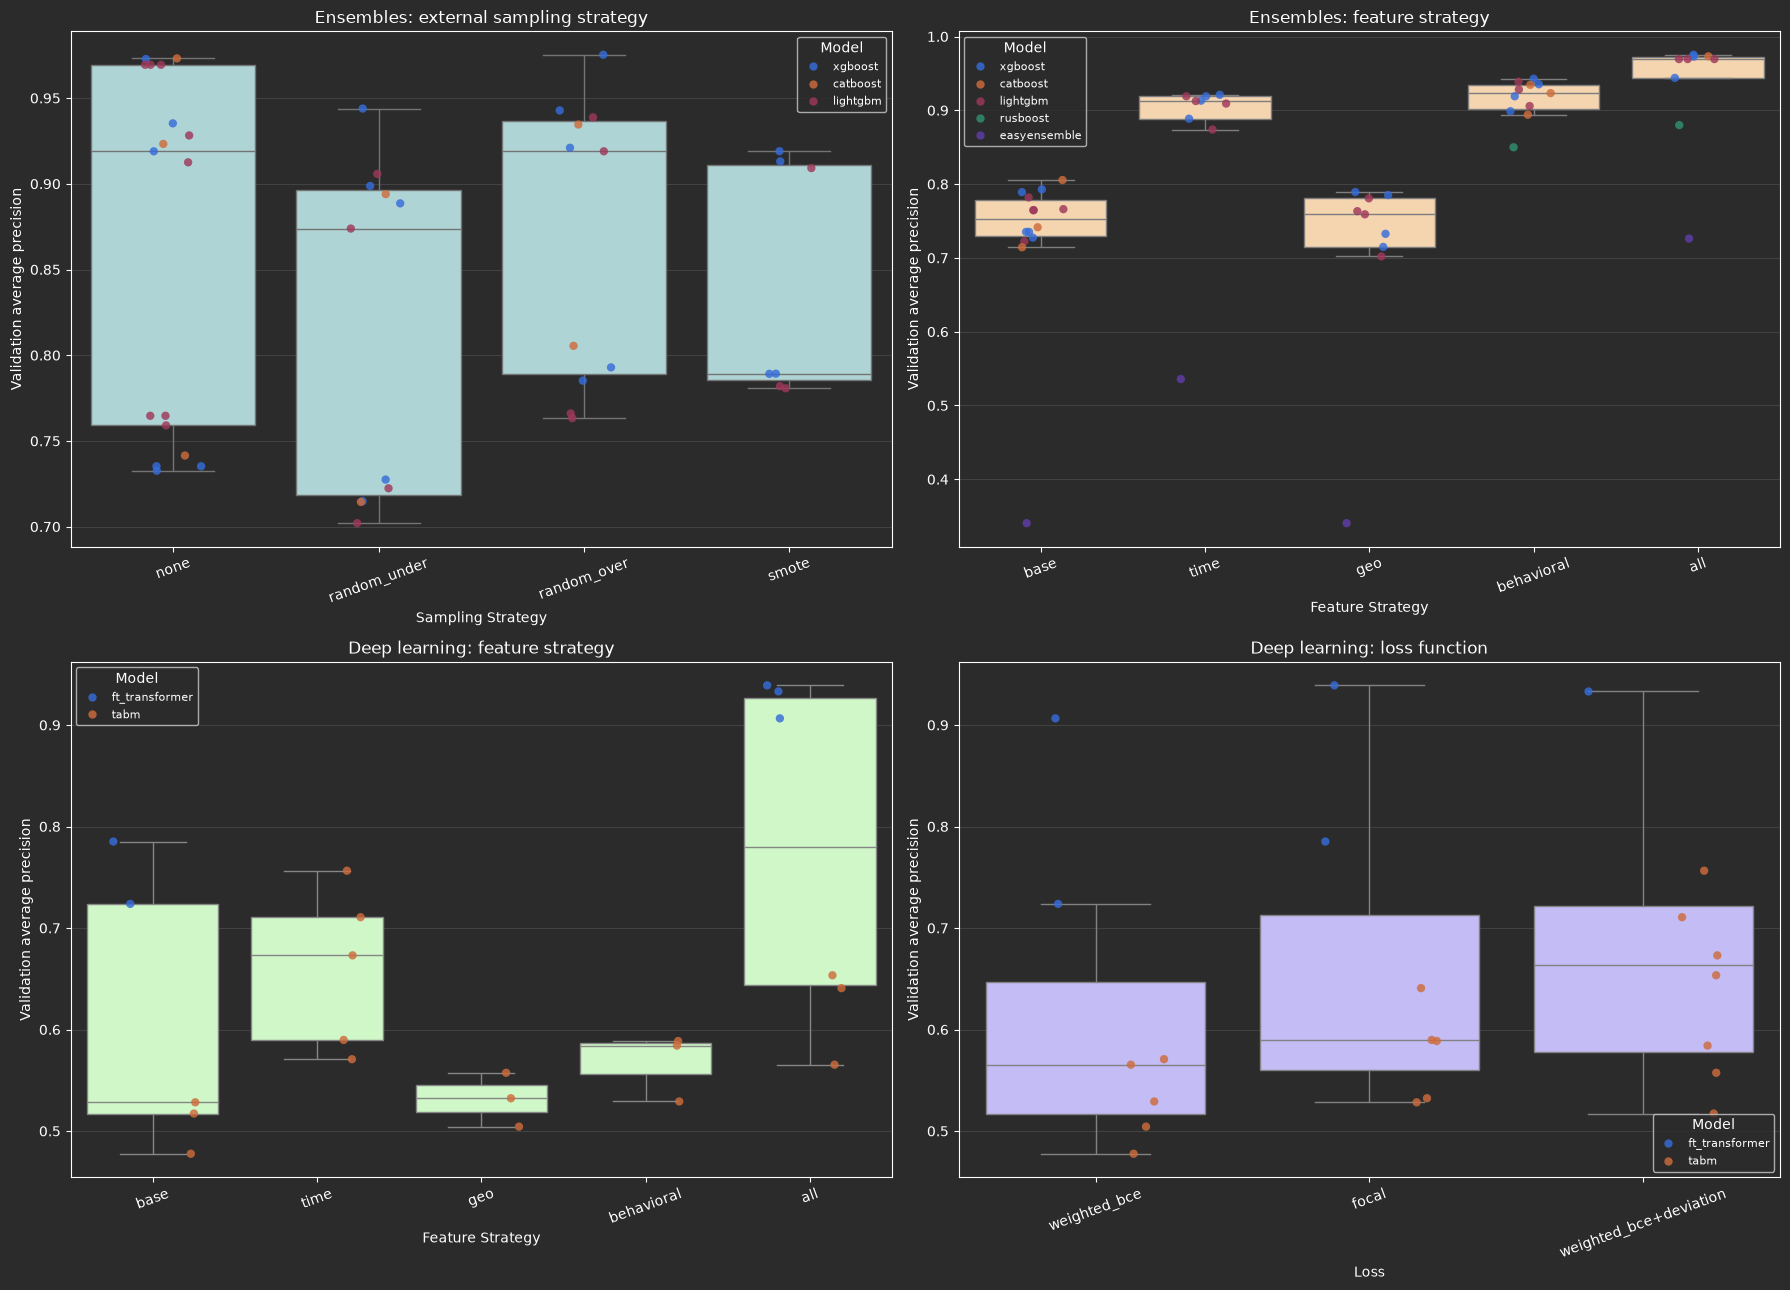

Ensemble external-sampling summary:


,experiments,mean,median,best
sampling_strategy,,,,
random_over,11,0.867660,0.918965,0.975271
none,17,0.865024,0.918939,0.973164
smote,7,0.840327,0.789235,0.919011
random_under,11,0.816917,0.873894,0.943894


Ensemble feature summary:


,experiments,mean,median,best
feature_strategy,,,,
all,9,0.931060,0.969419,0.975271
behavioral,11,0.915477,0.923266,0.942783
time,9,0.865773,0.912515,0.921008
base,14,0.727261,0.753085,0.805483
geo,9,0.707509,0.759062,0.789235


Deep-learning feature summary:


,experiments,mean,median,best
feature_strategy,,,,
all,6,0.773053,0.780001,0.939080
time,5,0.660130,0.673058,0.756457
base,5,0.606415,0.528297,0.785197
behavioral,3,0.567316,0.584154,0.588680
geo,3,0.531341,0.532305,0.557398


Deep-learning loss summary:


,experiments,mean,median,best
loss,,,,
weighted_bce+deviation,8,0.673185,0.663248,0.933109
focal,7,0.657722,0.589714,0.939080
weighted_bce,7,0.611068,0.565346,0.906563


In [31]:
score = "validation_average_precision"
feature_order = ["base", "time", "geo", "behavioral", "all"]
sampling_order = ["none", "random_under", "random_over", "smote"]
loss_order = ["weighted_bce", "focal", "weighted_bce+deviation"]

external_sampling_results = ensemble_results.loc[
    ~ensemble_results["model"].isin(["easyensemble", "rusboost"])
].dropna(subset=[score, "sampling_strategy"])
ensemble_feature_results = ensemble_results.dropna(subset=[score, "feature_strategy"])
deep_plot_results = deep_results.dropna(subset=[score])

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
plot_specs = [
    (external_sampling_results, "sampling_strategy", sampling_order, "Ensembles: external sampling strategy", "#a8dadc", False),
    (ensemble_feature_results, "feature_strategy", feature_order, "Ensembles: feature strategy", "#ffd6a5", False),
    (deep_plot_results, "feature_strategy", feature_order, "Deep learning: feature strategy", "#caffbf", True),
    (deep_plot_results, "loss", loss_order, "Deep learning: loss function", "#bdb2ff", True),
]

for axis, (frame, factor, order, title, color, dodge) in zip(axes.flat, plot_specs):
    sns.boxplot(
        data=frame, x=factor, y=score, order=order, color=color,
        showfliers=False, ax=axis,
    )
    sns.stripplot(
        data=frame, x=factor, y=score, order=order, hue="model",
        dodge=dodge, jitter=0.15, alpha=0.82, size=6, ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel(factor.replace("_", " ").title())
    axis.set_ylabel("Validation average precision")
    axis.tick_params(axis="x", rotation=20)
    axis.grid(axis="y", alpha=0.25)
    axis.legend(title="Model", fontsize=8)

plt.tight_layout()
plt.show()

def influence_summary(frame, factor):
    return (
        frame.groupby(factor, dropna=False)[score]
        .agg(experiments="count", mean="mean", median="median", best="max")
        .sort_values("mean", ascending=False)
    )

print("Ensemble external-sampling summary:")
display(influence_summary(external_sampling_results, "sampling_strategy"))
print("Ensemble feature summary:")
display(influence_summary(ensemble_feature_results, "feature_strategy"))
print("Deep-learning feature summary:")
display(influence_summary(deep_plot_results, "feature_strategy"))
print("Deep-learning loss summary:")
display(influence_summary(deep_plot_results, "loss"))